In [0]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, lit, to_timestamp, unix_timestamp
from pyspark.sql.types import *
import mlflow

spark = SparkSession.builder.appName("YatriSahayak").getOrCreate()
print("✅ Spark ready")

✅ Spark ready


In [0]:
# Read CSV


df = spark.table("bricksiitm.default.synthetic_railway_data")
df.printSchema()
df.show(5)

root
 |-- Train_id: string (nullable = true)
 |-- Train_name: string (nullable = true)
 |-- Train_no: long (nullable = true)
 |-- Source: string (nullable = true)
 |-- Destitnation: string (nullable = true)
 |-- Date: date (nullable = true)
 |-- Distance(Km): long (nullable = true)
 |-- Sc_arr__time: timestamp (nullable = true)
 |-- Act_arr_time: timestamp (nullable = true)
 |-- Dealy_min: timestamp (nullable = true)
 |-- Season: string (nullable = true)
 |-- Run_frequency: string (nullable = true)
 |-- Total_Delay_Minutes: double (nullable = true)

+--------+-----------------+--------+--------+------------+----------+------------+-------------------+-------------------+-------------------+------+-------------+-------------------+
|Train_id|       Train_name|Train_no|  Source|Destitnation|      Date|Distance(Km)|       Sc_arr__time|       Act_arr_time|          Dealy_min|Season|Run_frequency|Total_Delay_Minutes|
+--------+-----------------+--------+--------+------------+----------+----

In [0]:
from pyspark.sql.functions import col, hour, dayofweek, month, when

# Clean and create features
df_clean = df.select(
    col("Train_id"),
    col("Train_name"),
    col("Train_no"),
    col("Source"),
    col("Destitnation"),
    col("Distance(Km)").alias("Distance_Km"),
    col("Season"),
    col("Run_frequency"),
    col("Total_Delay_Minutes").alias("Delay_Minutes"),
    hour(col("Sc_arr__time")).alias("Scheduled_Hour"),
    dayofweek(col("Date")).alias("Day_of_Week"),
    month(col("Date")).alias("Month")
).dropna()

# Save cleaned data as Delta table
df_clean.write.format("delta").mode("overwrite").saveAsTable("train_delays_clean")

print(f"✅ Clean table ready: {df_clean.count()} rows")

# Check delay stats
from pyspark.sql.functions import min as spark_min, max as spark_max, avg as spark_avg
df_clean.select(
    spark_min("Delay_Minutes").alias("Min_Delay"),
    spark_max("Delay_Minutes").alias("Max_Delay"),
    spark_avg("Delay_Minutes").alias("Avg_Delay")
).show()

df_clean.show(5)

✅ Clean table ready: 1000 rows
+---------+------------------+-----------------+
|Min_Delay|         Max_Delay|        Avg_Delay|
+---------+------------------+-----------------+
|      0.0|142.46976244611417|46.42407070025921|
+---------+------------------+-----------------+

+--------+-----------------+--------+--------+------------+-----------+------+-------------+------------------+--------------+-----------+-----+
|Train_id|       Train_name|Train_no|  Source|Destitnation|Distance_Km|Season|Run_frequency|     Delay_Minutes|Scheduled_Hour|Day_of_Week|Month|
+--------+-----------------+--------+--------+------------+-----------+------+-------------+------------------+--------------+-----------+-----+
|      E1|Begampura Express|   12238|Varanasi|       Jammu|       1260|Winter|        Daliy| 72.94161107895245|             6|          2|    1|
|      E2|Begampura Express|   12238|Varanasi|       Jammu|       1260|Winter|        Daliy|22.360582228802475|             6|          5|   12

In [0]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml import Pipeline

# Encode categorical columns
season_indexer = StringIndexer(inputCol="Season", outputCol="Season_idx", handleInvalid="keep")
freq_indexer = StringIndexer(inputCol="Run_frequency", outputCol="Freq_idx", handleInvalid="keep")
source_indexer = StringIndexer(inputCol="Source", outputCol="Source_idx", handleInvalid="keep")
dest_indexer = StringIndexer(inputCol="Destitnation", outputCol="Dest_idx", handleInvalid="keep")

# Combine all features
assembler = VectorAssembler(
    inputCols=[
        "Distance_Km",
        "Scheduled_Hour",
        "Day_of_Week",
        "Month",
        "Season_idx",
        "Freq_idx",
        "Source_idx",
        "Dest_idx"
    ],
    outputCol="features"
)

prep_pipeline = Pipeline(stages=[season_indexer, freq_indexer, source_indexer, dest_indexer, assembler])
pipeline_model = prep_pipeline.fit(df_clean)
df_prepared = pipeline_model.transform(df_clean)

print("✅ Features ready")
df_prepared.select("Train_name", "Delay_Minutes", "features").show(5, truncate=False)

✅ Features ready
+-----------------+------------------+-------------------------------------+
|Train_name       |Delay_Minutes     |features                             |
+-----------------+------------------+-------------------------------------+
|Begampura Express|72.94161107895245 |[1260.0,6.0,2.0,1.0,0.0,0.0,1.0,0.0] |
|Begampura Express|22.360582228802475|[1260.0,6.0,5.0,12.0,0.0,0.0,1.0,0.0]|
|Begampura Express|70.58655844329436 |[1260.0,6.0,3.0,1.0,0.0,0.0,1.0,0.0] |
|Begampura Express|32.74543414740217 |[1260.0,6.0,4.0,12.0,0.0,0.0,1.0,0.0]|
|Begampura Express|34.08448649909869 |[1260.0,6.0,2.0,12.0,0.0,0.0,1.0,0.0]|
+-----------------+------------------+-------------------------------------+
only showing top 5 rows


In [0]:
import os
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
import mlflow

# Set UC volume path for MLflow temporary storage (required for serverless)
os.environ['MLFLOW_DFS_TMP'] = '/Volumes/bricksiitm/default/hackathon-submission-volume'

# Split
train_data, test_data = df_prepared.randomSplit([0.8, 0.2], seed=42)

with mlflow.start_run(run_name="YatriSahayak_GBT_Regressor"):
    
    gbt = GBTRegressor(
        labelCol="Delay_Minutes",
        featuresCol="features",
        maxIter=20,
        maxDepth=5
    )
    
    model = gbt.fit(train_data)
    predictions = model.transform(test_data)
    
    # Evaluate
    rmse_eval = RegressionEvaluator(labelCol="Delay_Minutes", metricName="rmse")
    mae_eval = RegressionEvaluator(labelCol="Delay_Minutes", metricName="mae")
    r2_eval = RegressionEvaluator(labelCol="Delay_Minutes", metricName="r2")
    
    rmse = rmse_eval.evaluate(predictions)
    mae = mae_eval.evaluate(predictions)
    r2 = r2_eval.evaluate(predictions)
    
    # Log to MLflow
    mlflow.log_param("model_type", "GBTRegressor")
    mlflow.log_param("maxIter", 20)
    mlflow.log_param("maxDepth", 5)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("R2", r2)
    
    # Log the SparkML model (now with UC volume configured)
    mlflow.spark.log_model(model, "gbt_delay_model")
    
    print(f"✅ Model trained and logged to MLflow")
    print(f"   RMSE: {rmse:.2f} minutes")
    print(f"   MAE:  {mae:.2f} minutes")
    print(f"   R²:   {r2:.4f}")

# Show sample predictions
predictions.select("Train_name", "Delay_Minutes", "prediction").show(10)

2026/04/25 09:07:06 WARNING mlflow.utils.requirements_utils: Found pyspark version (4.1.0+databricks.connect.18.0.2) contains a local version label (+databricks.connect.18.0.2). MLflow logged a pip requirement for this package as 'pyspark==4.1.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/25 09:07:10 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /local_disk0/user_tmp_data/spark-50bde427-b221-4d2f-a28c-bd/tmp9pmkg4i_/model, flavor: spark). Fall back to return ['pyspark==4.1.0']. Set logging level to DEBUG to see the full traceback. 
2026/04/25 09:07:10 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when l

✅ Model trained and logged to MLflow
   RMSE: 32.19 minutes
   MAE:  26.20 minutes
   R²:   0.1365
+-----------------+------------------+------------------+
|       Train_name|     Delay_Minutes|        prediction|
+-----------------+------------------+------------------+
|Begampura Express| 52.72705983917142|45.902282178378336|
|Begampura Express|61.941538715501125| 49.55628845122192|
|Begampura Express| 62.59356122844325|47.385640376429926|
|Begampura Express| 67.64875304336307| 38.26146261815173|
|Begampura Express| 72.28950236566048| 41.60954917634176|
|Begampura Express| 75.87053321788099|48.109662478199816|
|Begampura Express|   79.453072955919|61.829483084197506|
|Begampura Express| 85.94438288743933|48.109662478199816|
|Begampura Express| 94.90598313075488|48.109662478199816|
|Begampura Express| 95.18509776279846|61.829483084197506|
+-----------------+------------------+------------------+
only showing top 10 rows


In [0]:
from pyspark.sql import Row

# Railway passenger rights based on delay duration
rules_data = [
    Row(min_delay=0, max_delay=30, entitlement="No compensation applicable",
        rule_ref="N/A",
        hi="कोई मुआवजा लागू नहीं",
        ta="இழப்பீடு பொருந்தாது"),
    Row(min_delay=31, max_delay=60, entitlement="Eligible for complimentary drinking water and waiting room access",
        rule_ref="Rule 401(1)",
        hi="मुफ्त पीने का पानी और प्रतीक्षालय",
        ta="இலவச குடிநீர் மற்றும் காத்திருப்பு அறை"),
    Row(min_delay=61, max_delay=120, entitlement="Eligible for complimentary meals in addition to waiting room access",
        rule_ref="Rule 401(2)",
        hi="मुफ्त भोजन और प्रतीक्षालय",
        ta="இலவச உணவு மற்றும் காத்திருப்பு அறை"),
    Row(min_delay=121, max_delay=300, entitlement="Eligible for full ticket refund upon request",
        rule_ref="Rule 213",
        hi="अनुरोध पर पूर्ण टिकट रिफंड का हक",
        ta="கோரிக்கையின் பேரில் முழு டிக்கெட் பணத்தை திரும்பப் பெறலாம்"),
    Row(min_delay=301, max_delay=9999, entitlement="Eligible for full refund plus alternative transport arrangement",
        rule_ref="Rule 213 + Rule 402",
        hi="पूर्ण रिफंड और वैकल्पिक परिवहन व्यवस्था",
        ta="முழு பணத்தைத் திரும்பப் பெறுதல் மற்றும் மாற்று போக்குவரத்து")
]

rules_df = spark.createDataFrame(rules_data)
rules_df.write.format("delta").mode("overwrite").saveAsTable("passenger_rights_rules")

print("✅ Rules table created")
rules_df.show(truncate=False)

✅ Rules table created
+---------+---------+-------------------------------------------------------------------+-------------------+---------------------------------------+-----------------------------------------------------------+
|min_delay|max_delay|entitlement                                                        |rule_ref           |hi                                     |ta                                                         |
+---------+---------+-------------------------------------------------------------------+-------------------+---------------------------------------+-----------------------------------------------------------+
|0        |30       |No compensation applicable                                         |N/A                |कोई मुआवजा लागू नहीं                   |இழப்பீடு பொருந்தாது                                        |
|31       |60       |Eligible for complimentary drinking water and waiting room access  |Rule 401(1)        |मुफ्त पीने का पानी और प्रतीक्

In [0]:
# Create widgets
train_names = [row.Train_name for row in df_clean.select("Train_name").distinct().collect()]
seasons = [row.Season for row in df_clean.select("Season").distinct().collect()]

dbutils.widgets.dropdown("Train", train_names[0], train_names)
dbutils.widgets.dropdown("Season", seasons[0], seasons)
dbutils.widgets.dropdown("Language", "English", ["English", "Hindi", "Tamil"])

In [0]:
# Get widget values
selected_train = dbutils.widgets.get("Train")
selected_season = dbutils.widgets.get("Season")
selected_lang = dbutils.widgets.get("Language")

# Get average stats for this train + season combo
from pyspark.sql.functions import avg as spark_avg, count

stats = df_prepared.filter(
    (col("Train_name") == selected_train) & (col("Season") == selected_season)
)

if stats.count() == 0:
    print(f"⚠️ No data for {selected_train} in {selected_season}")
else:
    # Run prediction on matching rows
    preds = model.transform(stats)
    avg_pred = preds.select(spark_avg("prediction")).collect()[0][0]
    avg_actual = preds.select(spark_avg("Delay_Minutes")).collect()[0][0]
    
    predicted_delay = round(avg_pred, 1)
    
    # Look up rights from rules table
    rights = spark.sql(f"""
        SELECT entitlement, rule_ref, hi, ta 
        FROM passenger_rights_rules 
        WHERE {predicted_delay} >= min_delay AND {predicted_delay} <= max_delay
    """).collect()
    
    if rights:
        rule = rights[0]
        
        # Language selection
        if selected_lang == "Hindi":
            entitlement_text = rule["hi"]
        elif selected_lang == "Tamil":
            entitlement_text = rule["ta"]
        else:
            entitlement_text = rule["entitlement"]
        
        # Display result
        displayHTML(f"""
        <div style="font-family: Arial; padding: 20px; background: #1a1a2e; border-radius: 12px; color: white; max-width: 600px;">
            <h2 style="color: #e94560;">🚆 Yatri Sahayak</h2>
            <hr style="border-color: #e94560;">
            <p><b>Train:</b> {selected_train}</p>
            <p><b>Season:</b> {selected_season}</p>
            <p><b>Predicted Delay:</b> <span style="font-size: 28px; color: #e94560;">{predicted_delay} min</span></p>
            <p><b>Historical Avg Delay:</b> {round(avg_actual, 1)} min</p>
            <hr>
            <h3 style="color: #0f3460;">📋 Your Rights</h3>
            <p style="font-size: 18px; background: #16213e; padding: 15px; border-radius: 8px;">{entitlement_text}</p>
            <p style="color: #888;">Reference: {rule["rule_ref"]}</p>
        </div>
        """)
    else:
        print("❌ No matching rule found")

🚆 Yatri Sahayak 
 
 Train: Begampura Express 
 Season: Winter 
 Predicted Delay: 43.3 min 
 Historical Avg Delay: 43.3 min 
 
 📋 Your Rights 
 Eligible for complimentary drinking water and waiting room access 
 Reference: Rule 401(1)

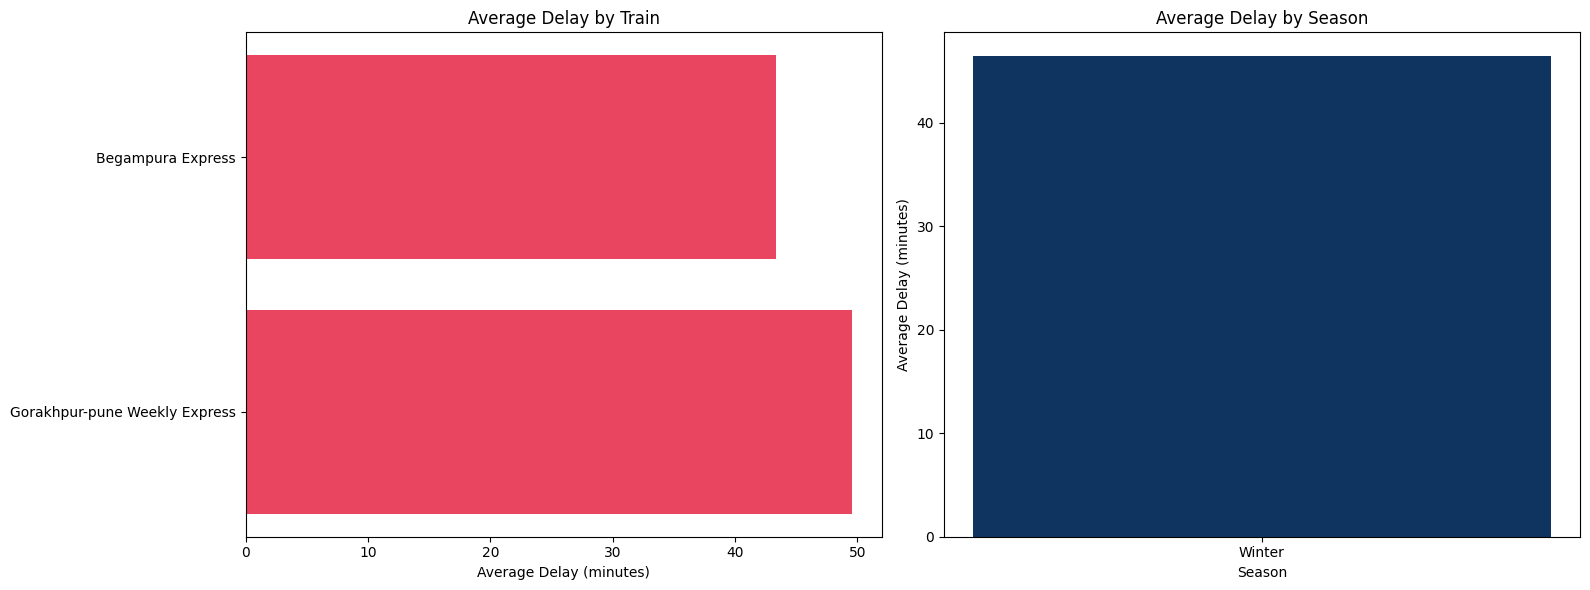

✅ Analytics charts ready


In [0]:
import matplotlib.pyplot as plt
import pandas as pd

# Delay by train
delay_by_train = df_clean.groupBy("Train_name").agg(
    spark_avg("Delay_Minutes").alias("Avg_Delay")
).orderBy("Avg_Delay", ascending=False).toPandas()

# Delay by season
delay_by_season = df_clean.groupBy("Season").agg(
    spark_avg("Delay_Minutes").alias("Avg_Delay")
).toPandas()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1
ax1.barh(delay_by_train["Train_name"], delay_by_train["Avg_Delay"], color="#e94560")
ax1.set_xlabel("Average Delay (minutes)")
ax1.set_title("Average Delay by Train")

# Chart 2
ax2.bar(delay_by_season["Season"], delay_by_season["Avg_Delay"], color="#0f3460")
ax2.set_xlabel("Season")
ax2.set_ylabel("Average Delay (minutes)")
ax2.set_title("Average Delay by Season")

plt.tight_layout()
plt.savefig("/tmp/delay_analytics.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Analytics charts ready")

In [0]:
from pyspark.sql.functions import avg as spark_avg, col, count, min as spark_min, max as spark_max
import json

# ---------- 1. Gather data from Delta Lake ----------
# Get all train + season combos with predictions
combos = df_prepared.select("Train_name", "Train_no", "Source", "Destitnation", "Distance_Km", "Season").distinct().collect()

# Build prediction data for every combo
train_meta = {}
prediction_map = {}

for row in combos:
    tname = row["Train_name"]
    season = row["Season"]
    
    if tname not in train_meta:
        train_meta[tname] = {
            "no": str(row["Train_no"]),
            "src": row["Source"],
            "dest": row["Destitnation"],
            "dist": int(row["Distance_Km"]),
            "delays": {}
        }
    
    subset = df_prepared.filter(
        (col("Train_name") == tname) & (col("Season") == season)
    )
    
    preds = model.transform(subset)
    avg_pred = preds.select(spark_avg("prediction")).collect()[0][0]
    avg_actual = preds.select(spark_avg("Delay_Minutes")).collect()[0][0]
    
    train_meta[tname]["delays"][season] = {
        "predicted": round(avg_pred, 1),
        "actual": round(avg_actual, 1)
    }

# Get rules
rules_rows = spark.sql("SELECT * FROM passenger_rights_rules ORDER BY min_delay").collect()
rules_json = []
for r in rules_rows:
    rules_json.append({
        "min": r["min_delay"], "max": r["max_delay"],
        "en": r["entitlement"], "hi": r["hi"], "ta": r["ta"],
        "rule": r["rule_ref"]
    })

# Get delay stats for charts
delay_by_train = df_clean.groupBy("Train_name").agg(
    spark_avg("Delay_Minutes").alias("avg"),
    spark_min("Delay_Minutes").alias("min_d"),
    spark_max("Delay_Minutes").alias("max_d"),
    count("*").alias("cnt")
).toPandas().to_dict('records')

delay_by_season = df_clean.groupBy("Season").agg(
    spark_avg("Delay_Minutes").alias("avg")
).toPandas().to_dict('records')

# Serialize to JSON for the HTML
train_json = json.dumps(train_meta)
rules_j = json.dumps(rules_json)
chart_train_j = json.dumps(delay_by_train)
chart_season_j = json.dumps(delay_by_season)

# ---------- 2. Render Dashboard ----------
displayHTML(f"""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<style>
  @import url('https://fonts.googleapis.com/css2?family=Outfit:wght@300;400;500;600;700;800&family=JetBrains+Mono:wght@400;500;600&display=swap');

  :root {{
    --bg: #06080c;
    --card: #0c1018;
    --elevated: #111822;
    --border: #1c2636;
    --accent: #e94560;
    --accent-glow: rgba(233,69,96,0.15);
    --amber: #f59e0b;
    --green: #22c55e;
    --blue: #3b82f6;
    --text: #e8ecf1;
    --text2: #6b7a90;
    --text3: #3d4d63;
  }}

  * {{ margin:0; padding:0; box-sizing:border-box; }}

  .ys-app {{
    font-family: 'Outfit', sans-serif;
    background: var(--bg);
    color: var(--text);
    padding: 32px 24px;
    min-height: 100vh;
  }}

  .ys-header {{
    text-align: center;
    margin-bottom: 36px;
  }}

  .ys-badge {{
    display: inline-flex;
    align-items: center;
    gap: 8px;
    background: var(--accent-glow);
    border: 1px solid rgba(233,69,96,0.3);
    border-radius: 100px;
    padding: 5px 14px;
    font-family: 'JetBrains Mono', monospace;
    font-size: 10px;
    color: var(--accent);
    text-transform: uppercase;
    letter-spacing: 2px;
    margin-bottom: 16px;
  }}

  .ys-badge .dot {{
    width: 6px; height: 6px;
    background: var(--accent);
    border-radius: 50%;
    animation: pulse 2s infinite;
  }}

  .ys-header h1 {{
    font-size: 38px;
    font-weight: 800;
    letter-spacing: -1px;
  }}

  .ys-header h1 span {{ color: var(--accent); }}

  .ys-header p {{
    color: var(--text2);
    font-size: 15px;
    font-weight: 300;
    margin-top: 8px;
  }}

  /* Controls */
  .ys-controls {{
    display: grid;
    grid-template-columns: 1fr 1fr 1fr auto;
    gap: 14px;
    margin-bottom: 28px;
    align-items: end;
  }}

  .ys-field {{ display: flex; flex-direction: column; gap: 6px; }}

  .ys-field label {{
    font-family: 'JetBrains Mono', monospace;
    font-size: 10px;
    color: var(--text3);
    text-transform: uppercase;
    letter-spacing: 1.5px;
  }}

  .ys-field select {{
    background: var(--elevated);
    border: 1px solid var(--border);
    border-radius: 8px;
    color: var(--text);
    font-family: 'Outfit', sans-serif;
    font-size: 14px;
    font-weight: 500;
    padding: 12px 14px;
    cursor: pointer;
    appearance: none;
    background-image: url("data:image/svg+xml,%3Csvg xmlns='http://www.w3.org/2000/svg' width='12' height='12' viewBox='0 0 24 24' fill='none' stroke='%236b7a90' stroke-width='2'%3E%3Cpath d='m6 9 6 6 6-6'/%3E%3C/svg%3E");
    background-repeat: no-repeat;
    background-position: right 12px center;
    transition: border-color 0.2s;
  }}

  .ys-field select:focus {{ outline: none; border-color: var(--accent); }}

  .ys-btn {{
    background: var(--accent);
    border: none;
    border-radius: 8px;
    color: white;
    font-family: 'Outfit', sans-serif;
    font-size: 14px;
    font-weight: 600;
    padding: 12px 28px;
    cursor: pointer;
    transition: all 0.2s;
    white-space: nowrap;
    height: fit-content;
  }}

  .ys-btn:hover {{
    transform: translateY(-1px);
    box-shadow: 0 6px 20px rgba(233,69,96,0.3);
  }}

  /* Cards Grid */
  .ys-cards {{
    display: grid;
    grid-template-columns: 1fr 1fr 1fr 1fr;
    gap: 14px;
    margin-bottom: 20px;
  }}

  .ys-card {{
    background: var(--card);
    border: 1px solid var(--border);
    border-radius: 10px;
    padding: 22px;
    opacity: 0;
    transform: translateY(10px);
    transition: all 0.4s ease-out;
  }}

  .ys-card.show {{ opacity: 1; transform: translateY(0); }}

  .ys-card-label {{
    font-family: 'JetBrains Mono', monospace;
    font-size: 10px;
    color: var(--text3);
    text-transform: uppercase;
    letter-spacing: 1.5px;
    margin-bottom: 10px;
  }}

  .ys-card-val {{
    font-size: 34px;
    font-weight: 700;
    letter-spacing: -1px;
    line-height: 1;
    margin-bottom: 4px;
  }}

  .ys-card-val small {{
    font-size: 16px;
    font-weight: 400;
  }}

  .ys-card-sub {{
    font-size: 12px;
    color: var(--text2);
  }}

  .c-amber .ys-card-val {{ color: var(--amber); }}
  .c-blue .ys-card-val {{ color: var(--blue); }}
  .c-green .ys-card-val {{ color: var(--green); }}
  .c-white .ys-card-val {{ color: var(--text); font-size: 17px; line-height: 1.3; }}

  /* Meter */
  .ys-meter {{
    margin-bottom: 20px;
    opacity: 0;
    transition: opacity 0.4s;
  }}

  .ys-meter.show {{ opacity: 1; }}

  .ys-meter-label {{
    font-family: 'JetBrains Mono', monospace;
    font-size: 10px;
    color: var(--text3);
    text-transform: uppercase;
    letter-spacing: 1.5px;
    margin-bottom: 10px;
  }}

  .ys-meter-track {{
    height: 6px;
    background: var(--elevated);
    border-radius: 100px;
    overflow: hidden;
  }}

  .ys-meter-fill {{
    height: 100%;
    border-radius: 100px;
    background: linear-gradient(90deg, var(--green), var(--amber), var(--accent));
    transition: width 1s ease-out;
    width: 0%;
  }}

  .ys-meter-stops {{
    display: flex;
    justify-content: space-between;
    margin-top: 6px;
    font-family: 'JetBrains Mono', monospace;
    font-size: 9px;
    color: var(--text3);
  }}

  .ys-meter-stops .active {{ color: var(--accent); font-weight: 600; }}

  /* Rights */
  .ys-rights {{
    background: var(--card);
    border: 1px solid var(--border);
    border-radius: 10px;
    padding: 28px;
    position: relative;
    overflow: hidden;
    margin-bottom: 20px;
    opacity: 0;
    transform: translateY(10px);
    transition: all 0.5s ease-out;
  }}

  .ys-rights.show {{
    opacity: 1;
    transform: translateY(0);
    border-color: var(--accent);
  }}

  .ys-rights::before {{
    content: '';
    position: absolute;
    top: 0; left: 0; right: 0;
    height: 3px;
    background: linear-gradient(90deg, var(--accent), var(--amber), var(--accent));
  }}

  .ys-rights-head {{
    display: flex;
    align-items: center;
    gap: 10px;
    margin-bottom: 16px;
  }}

  .ys-rights-icon {{
    width: 40px; height: 40px;
    background: var(--accent-glow);
    border: 1px solid rgba(233,69,96,0.3);
    border-radius: 8px;
    display: flex;
    align-items: center;
    justify-content: center;
    font-size: 20px;
  }}

  .ys-rights-title {{ font-size: 16px; font-weight: 700; }}

  .ys-rights-rule {{
    font-family: 'JetBrains Mono', monospace;
    font-size: 11px;
    color: var(--accent);
    margin-left: auto;
    background: var(--accent-glow);
    padding: 3px 10px;
    border-radius: 6px;
  }}

  .ys-rights-text {{
    font-size: 18px;
    font-weight: 500;
    line-height: 1.5;
    padding: 18px;
    background: var(--elevated);
    border-radius: 8px;
    border-left: 3px solid var(--accent);
    margin-bottom: 16px;
  }}

  .ys-translations {{
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 10px;
  }}

  .ys-trans-block {{
    background: var(--elevated);
    border-radius: 8px;
    padding: 14px;
  }}

  .ys-trans-lang {{
    font-family: 'JetBrains Mono', monospace;
    font-size: 9px;
    color: var(--text3);
    text-transform: uppercase;
    letter-spacing: 1.5px;
    margin-bottom: 6px;
  }}

  .ys-trans-text {{
    font-size: 14px;
    color: var(--text2);
    line-height: 1.5;
  }}

  /* Charts */
  .ys-charts {{
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 14px;
    margin-bottom: 28px;
    opacity: 0;
    transition: opacity 0.4s;
  }}

  .ys-charts.show {{ opacity: 1; }}

  .ys-chart-card {{
    background: var(--card);
    border: 1px solid var(--border);
    border-radius: 10px;
    padding: 22px;
  }}

  .ys-chart-title {{
    font-family: 'JetBrains Mono', monospace;
    font-size: 10px;
    color: var(--text3);
    text-transform: uppercase;
    letter-spacing: 1.5px;
    margin-bottom: 16px;
  }}

  .ys-bar-row {{
    display: flex;
    align-items: center;
    gap: 10px;
    margin-bottom: 10px;
  }}

  .ys-bar-label {{
    font-size: 12px;
    color: var(--text2);
    width: 120px;
    text-align: right;
    flex-shrink: 0;
    overflow: hidden;
    text-overflow: ellipsis;
    white-space: nowrap;
  }}

  .ys-bar-track {{
    flex: 1;
    height: 20px;
    background: var(--elevated);
    border-radius: 4px;
    overflow: hidden;
    position: relative;
  }}

  .ys-bar-fill {{
    height: 100%;
    border-radius: 4px;
    transition: width 0.8s ease-out;
  }}

  .ys-bar-val {{
    font-family: 'JetBrains Mono', monospace;
    font-size: 11px;
    color: var(--text2);
    width: 55px;
    text-align: right;
    flex-shrink: 0;
  }}

  /* Empty */
  .ys-empty {{
    text-align: center;
    padding: 60px 20px;
    color: var(--text3);
  }}

  .ys-empty .icon {{ font-size: 40px; margin-bottom: 12px; opacity: 0.4; }}
  .ys-empty p {{ font-size: 14px; }}

  /* Footer */
  .ys-footer {{
    text-align: center;
    padding-top: 24px;
    border-top: 1px solid var(--border);
  }}

  .ys-footer-label {{
    font-family: 'JetBrains Mono', monospace;
    font-size: 9px;
    color: var(--text3);
    text-transform: uppercase;
    letter-spacing: 2px;
    margin-bottom: 10px;
  }}

  .ys-pills {{ display: flex; justify-content: center; flex-wrap: wrap; gap: 6px; }}

  .ys-pill {{
    font-family: 'JetBrains Mono', monospace;
    font-size: 10px;
    color: var(--text2);
    background: var(--elevated);
    border: 1px solid var(--border);
    border-radius: 100px;
    padding: 4px 12px;
  }}

  @keyframes pulse {{
    0%,100% {{ opacity: 1; }}
    50% {{ opacity: 0.3; }}
  }}

  @media (max-width: 768px) {{
    .ys-controls {{ grid-template-columns: 1fr; }}
    .ys-cards {{ grid-template-columns: 1fr 1fr; }}
    .ys-charts {{ grid-template-columns: 1fr; }}
    .ys-translations {{ grid-template-columns: 1fr; }}
  }}
</style>
</head>
<body>
<div class="ys-app">

  <div class="ys-header">
    <div class="ys-badge"><span class="dot"></span>Rail-Drishti Track</div>
    <h1>🚆 Yatri <span>Sahayak</span></h1>
    <p>Predict train delays & know your passenger rights — in your language</p>
  </div>

  <div class="ys-controls">
    <div class="ys-field">
      <label>Select Train</label>
      <select id="ysTrain"></select>
    </div>
    <div class="ys-field">
      <label>Season</label>
      <select id="ysSeason"></select>
    </div>
    <div class="ys-field">
      <label>Language</label>
      <select id="ysLang">
        <option value="en">English</option>
        <option value="hi">Hindi — हिन्दी</option>
        <option value="ta">Tamil — தமிழ்</option>
      </select>
    </div>
    <button class="ys-btn" onclick="ysPredict()">Predict Delay →</button>
  </div>

  <div id="ysOutput">
    <div class="ys-empty">
      <div class="icon">🛤️</div>
      <p>Select a train and click Predict to see delay forecast & your rights</p>
    </div>
  </div>

  <!-- Charts (always visible) -->
  <div class="ys-charts show" id="ysCharts"></div>

  <div class="ys-footer">
    <div class="ys-footer-label">Powered by</div>
    <div class="ys-pills">
      <span class="ys-pill">Delta Lake</span>
      <span class="ys-pill">PySpark</span>
      <span class="ys-pill">Spark MLlib (GBT)</span>
      <span class="ys-pill">MLflow</span>
      <span class="ys-pill">Databricks</span>
    </div>
  </div>
</div>

<script>
const trainData = {train_json};
const rules = {rules_j};
const chartTrain = {chart_train_j};
const chartSeason = {chart_season_j};

// Populate dropdowns
const trainSel = document.getElementById('ysTrain');
const seasonSel = document.getElementById('ysSeason');

Object.keys(trainData).forEach(name => {{
  const o = document.createElement('option');
  o.value = name;
  o.textContent = name + ' (' + trainData[name].no + ')';
  trainSel.appendChild(o);
}});

// Get all seasons
const allSeasons = new Set();
Object.values(trainData).forEach(t => Object.keys(t.delays).forEach(s => allSeasons.add(s)));
allSeasons.forEach(s => {{
  const o = document.createElement('option');
  o.value = s;
  o.textContent = s;
  seasonSel.appendChild(o);
}});

// Render charts
function renderCharts() {{
  const container = document.getElementById('ysCharts');
  const maxDelay = Math.max(...chartTrain.map(d => d.avg));
  const maxSeason = Math.max(...chartSeason.map(d => d.avg));

  let trainBars = chartTrain.map(d => `
    <div class="ys-bar-row">
      <div class="ys-bar-label">${{d.Train_name}}</div>
      <div class="ys-bar-track">
        <div class="ys-bar-fill" style="width:${{(d.avg/maxDelay*100).toFixed(1)}}%;background:var(--accent);"></div>
      </div>
      <div class="ys-bar-val">${{d.avg.toFixed(1)}} min</div>
    </div>
  `).join('');

  let seasonBars = chartSeason.map(d => `
    <div class="ys-bar-row">
      <div class="ys-bar-label">${{d.Season}}</div>
      <div class="ys-bar-track">
        <div class="ys-bar-fill" style="width:${{(d.avg/maxSeason*100).toFixed(1)}}%;background:var(--blue);"></div>
      </div>
      <div class="ys-bar-val">${{d.avg.toFixed(1)}} min</div>
    </div>
  `).join('');

  container.innerHTML = `
    <div class="ys-chart-card">
      <div class="ys-chart-title">Average Delay by Train</div>
      ${{trainBars}}
    </div>
    <div class="ys-chart-card">
      <div class="ys-chart-title">Average Delay by Season</div>
      ${{seasonBars}}
    </div>
  `;
}}

renderCharts();

function ysPredict() {{
  const name = trainSel.value;
  const season = seasonSel.value;
  const lang = document.getElementById('ysLang').value;
  const out = document.getElementById('ysOutput');

  if (!name || !trainData[name]) return;

  const train = trainData[name];
  const delayData = train.delays[season];

  if (!delayData) {{
    out.innerHTML = `<div class="ys-empty"><div class="icon">⚠️</div><p>No data for ${{name}} in ${{season}}</p></div>`;
    return;
  }}

  const predicted = delayData.predicted;
  const actual = delayData.actual;

  // Find rule
  const rule = rules.find(r => predicted >= r.min && predicted <= r.max);
  if (!rule) return;

  const langMap = {{ en: 'en', hi: 'hi', ta: 'ta' }};
  const entitlement = rule[lang] || rule.en;

  const otherLangs = ['en','hi','ta'].filter(l => l !== lang);
  const langNames = {{ en: 'English', hi: 'Hindi · हिन्दी', ta: 'Tamil · தமிழ்' }};

  const meterPct = Math.min((predicted / 300) * 100, 100);

  const transBlocks = otherLangs.map(l => `
    <div class="ys-trans-block">
      <div class="ys-trans-lang">${{langNames[l]}}</div>
      <div class="ys-trans-text">${{rule[l]}}</div>
    </div>
  `).join('');

  out.innerHTML = `
    <div class="ys-cards">
      <div class="ys-card c-amber" id="c1">
        <div class="ys-card-label">Predicted Delay</div>
        <div class="ys-card-val">${{predicted}}<small> min</small></div>
        <div class="ys-card-sub">GBTRegressor · ${{season}}</div>
      </div>
      <div class="ys-card c-blue" id="c2">
        <div class="ys-card-label">Historical Average</div>
        <div class="ys-card-val">${{actual}}<small> min</small></div>
        <div class="ys-card-sub">${{name}}</div>
      </div>
      <div class="ys-card c-white" id="c3">
        <div class="ys-card-label">Route</div>
        <div class="ys-card-val">${{train.src}} → ${{train.dest}}</div>
        <div class="ys-card-sub">Train #${{train.no}} · ${{train.dist}} km</div>
      </div>
      <div class="ys-card c-green" id="c4">
        <div class="ys-card-label">Model Info</div>
        <div class="ys-card-val">GBT</div>
        <div class="ys-card-sub">RMSE: 32.19 · R²: 0.14</div>
      </div>
    </div>

    <div class="ys-meter" id="ysMeter">
      <div class="ys-meter-label">Delay Severity</div>
      <div class="ys-meter-track">
        <div class="ys-meter-fill" id="ysFill"></div>
      </div>
      <div class="ys-meter-stops">
        <span class="${{predicted <= 30 ? 'active' : ''}}">0</span>
        <span class="${{predicted > 30 && predicted <= 60 ? 'active' : ''}}">30 min</span>
        <span class="${{predicted > 60 && predicted <= 120 ? 'active' : ''}}">1 hr</span>
        <span class="${{predicted > 120 && predicted <= 300 ? 'active' : ''}}">2 hr</span>
        <span class="${{predicted > 300 ? 'active' : ''}}">5 hr+</span>
      </div>
    </div>

    <div class="ys-rights" id="ysRights">
      <div class="ys-rights-head">
        <div class="ys-rights-icon">📋</div>
        <span class="ys-rights-title">Your Passenger Rights</span>
        <span class="ys-rights-rule">${{rule.rule}}</span>
      </div>
      <div class="ys-rights-text">${{entitlement}}</div>
      <div class="ys-translations">${{transBlocks}}</div>
    </div>
  `;

  // Animate in
  setTimeout(() => document.getElementById('c1').classList.add('show'), 100);
  setTimeout(() => document.getElementById('c2').classList.add('show'), 200);
  setTimeout(() => document.getElementById('c3').classList.add('show'), 300);
  setTimeout(() => document.getElementById('c4').classList.add('show'), 400);
  setTimeout(() => {{
    document.getElementById('ysMeter').classList.add('show');
    setTimeout(() => document.getElementById('ysFill').style.width = meterPct + '%', 50);
  }}, 500);
  setTimeout(() => document.getElementById('ysRights').classList.add('show'), 700);
}}
</script>
</body>
</html>
""")

<!DOCTYPE html>
 
 
 

 
 
 

 
 Rail-Drishti Track 
 🚆 Yatri Sahayak 
 Predict train delays & know your passenger rights — in your language 
 

 
 
 Select Train 
 
 
 
 Season 
 
 
 
 Language 
 
 English 
 Hindi — हिन्दी 
 Tamil — தமிழ் 
 
 
 Predict Delay → 
 

 
 
 🛤️ 
 Select a train and click Predict to see delay forecast & your rights 
 
 

 <!-- Charts (always visible) -->
 

 
 Powered by 
 
 Delta Lake 
 PySpark 
 Spark MLlib (GBT) 
 MLflow 
 Databricks